### Test SNID-SAGE

This notebook will run SNID-SAGE on spectra of SN 2019odp

In [574]:
import os
import glob
import tabulate
import pandas as pd
import subprocess
from tabulate import tabulate
import warnings
import matplotlib.pyplot as plt
from io import StringIO
from astropy.io import fits
from astropy.io import ascii
import numpy as np
import astropy
from wiserep_api import download_target_spectra
import spectra
warnings.filterwarnings("ignore")
import runSNIDsage

Test a Single spectrum

In [2]:
# filepath = 'spectra/2019odp_2019-08-22_03-52-39.800_P60_SEDM_NOT-ZTF.ascii'

In [3]:
# result = runSNIDsage.run_SNID_SAGE(filepath)
# print(result)

Test a batch run

In [164]:
filepath = 'spectra/*'

In [165]:
runSNIDsage.run_SNID_SAGE_batch(filepath)

Starting batch analysis for 44 spectra
[1/44] 2024ggi_2460426.126_Lijiang-2.4m_YFOSC_None: II IIP z=0.003804±0.003952 age=4.3±10.6 Q_cluster=9.5 MatchQual=High TypeConf=High SubtypeConf=Medium
[2/44] 2024ggi_2025-05-26_NOT_ALFOSC_NOIRlab_NordicOpticalTelescope: II II-87A z=0.001886±0.000406 age=405.3±70.9 Q_cluster=11.2 MatchQual=High TypeConf=High SubtypeConf=Low
[3/44] 2024ggi_2460443.056_Lijiang-2.4m_YFOSC_None: II IIP z=0.002956±0.002497 age=15.8±20.6 Q_cluster=16.9 MatchQual=High TypeConf=High SubtypeConf=Medium
[4/44] 2024ggi_2460412.963_TNG_DOLORES_None: II II-flash z=0.002417±0.000373 age=-7.2±1.5 Q_cluster=29.2 MatchQual=High TypeConf=High SubtypeConf=High
[5/44] 2024ggi_2024-04-17_23-13-39.750_SALT_RSS_None: II IIP z=0.003723±0.003226 age=3.6±9.8 Q_cluster=7.6 MatchQual=High TypeConf=High SubtypeConf=Low
[6/44] 2024ggi_2460430.089_Lijiang-2.4m_YFOSC_None: II IIP z=0.001891±0.001702 age=3.5±8.1 Q_cluster=13.3 MatchQual=High TypeConf=High SubtypeConf=High
[7/44] 2024ggi_2460414

RUNNING SNID-SAGE...
####################################################################################################


In [3]:
# runSNIDsage.run_SNID_SAGE_batch(filepath)

Starting batch analysis for 30 spectra
[1/30] 2019odp_2019-09-01_04-56-30.000_P60_SEDM_NOT-ZTF: Ib Ib-pec z=0.015623±0.003114 age=-8.0±3.0 Q_cluster=9.8 MatchQual=High TypeConf=High SubtypeConf=High
[2/30] 2019odp_2020-01-13_20-27-34.858_NOT_ALFOSC_NOT-ZTF: II IIb z=0.014729±0.001111 age=147.4±70.3 Q_cluster=5.9 MatchQual=Medium TypeConf=Very Low SubtypeConf=High
[3/30] 2019odp_2019-08-30_23-35-50.890_NOT_ALFOSC_NOT-ZTF: Ib Ib-pec z=0.014921±0.000805 age=-9.2±1.0 Q_cluster=9.4 MatchQual=High TypeConf=High SubtypeConf=High
[4/30] SN2019odp_2019-08-24_21-15-54_P60_SEDM_TNS: Ib Ib-pec z=0.014962±0.002060 age=-15.0±2.2 Q_cluster=7.0 MatchQual=Medium TypeConf=High SubtypeConf=No Comp
[5/30] 2019odp_2019-12-21_03-58-23.598_P60_SEDM_NOT-ZTF: Ic Ic-norm z=0.015195±0.001791 age=129.6±67.3 Q_cluster=2.2 MatchQual=Very Low TypeConf=Low SubtypeConf=High
[6/30] 2019odp_2019-09-17_07-44-40.400_P60_SEDM_NOT-ZTF: Ib Ib-pec z=0.015069±0.001391 age=8.1±4.1 Q_cluster=13.3 MatchQual=High TypeConf=High Sub

## Read SNID-SAGE output

- [x] inspect snid run + results (epochs with errors or no matches found) 
- [x] read batch_results.cv 
- [x] print confirmation of a transition Y/N (confidence?)
- [x] novel classifications, epochs, and identification
- [ ] plot reported epochs w/best fitting classifications

In [7]:
filepath = "results_2008D/"

In [13]:
batch_results = pd.read_csv(filepath + "batch_results.csv")

In [15]:
batch_results.columns

Index(['file', 'path', 'type', 'subtype', 'z', 'z_err', 'age', 'age_err',
       'Q_cluster', 'match_quality', 'type_confidence', 'subtype_confidence',
       'second_best_subtype', 'best_template', 'zfixed', 'second_best_type',
       'second_best_type_subtype', 'second_best_type_subtype_z',
       'second_best_type_subtype_z_err', 'second_best_type_subtype_age',
       'second_best_type_subtype_age_err', 'success', 'error'],
      dtype='str')

In [16]:
batch_results["file"]

0       2008D_2008-01-25_00-00-00_WHT-4.2m_ISIS_SUSPECT
1     SN2008D_2008-02-27_00-00-00_Magellan-Clay_LDSS...
2       2008D_2008-01-10_00-00-00_VLT-UT1_FORS2_SUSPECT
3     SN_2008D_2008-02-12_10-19-12_Keck1_LRIS_UCB-SN...
4     SN2008D_2008-02-01_08-09-36_FLWO-1.5m_FAST_CfA...
                            ...                        
66    SN_2008D_2008-01-14_09-37-26_Lick-3m_KAST_UCB-...
67        SN2008D_2008-01-12_00-00-00_MMT_MMT-Blue_None
68    SN2008D_2008-01-16_07-55-12_MMT_MMT-Blue_CfA-S...
69         2008D_2008-01-16_00-00-00_NOT_ALFOSC_SUSPECT
70          SN2008D_2008-04-28_00-00-00_Keck1_LRIS_None
Name: file, Length: 71, dtype: str

In [48]:
filenames = np.array(batch_results["file"])

In [49]:
import re

#get epoch from filenames (standard convention)

#Look for a pattern in the filename that matches YYYY-MM-DD or YYYYMMDD
# ( \d{4}-\d{2}-\d{2} )  -> Matches YYYY-MM-DD
# |                      -> OR
# ( \d{8} )              -> Matches YYYYMMDD (8 digits)
date_pattern = re.compile(r'(\d{4}-\d{2}-\d{2})|(\d{8})')


# make an array of dates "date"
date = np.array([])

for name in filenames:
    match = date_pattern.search(name)
    if match:
        # result is whichever group (1 or 2) found a hit
        date_str = match.group(0)
        date = np.append(date, date_str)
        
batch_results["date"] = pd.to_datetime(date) #make it a pd.datetime object for sorting

In [50]:
batch_results.columns

Index(['file', 'path', 'type', 'subtype', 'z', 'z_err', 'age', 'age_err',
       'Q_cluster', 'match_quality', 'type_confidence', 'subtype_confidence',
       'second_best_subtype', 'best_template', 'zfixed', 'second_best_type',
       'second_best_type_subtype', 'second_best_type_subtype_z',
       'second_best_type_subtype_z_err', 'second_best_type_subtype_age',
       'second_best_type_subtype_age_err', 'success', 'error', 'date'],
      dtype='str')

In [317]:
#construct a dataframe of relevant info
result_df = pd.DataFrame({"file": batch_results["file"],
                          "date": batch_results["date"],
                          "type": batch_results["type"],
                          "subtype":batch_results["subtype"],
                          "match_quality": batch_results["match_quality"],
                          "best_template": batch_results["best_template"],
                          "type_confidence": batch_results["type_confidence"],
                          "second_best_type": batch_results["second_best_type"],
                          "subtype_confidence":batch_results["subtype_confidence"],
                          "second_best_subtype": batch_results["second_best_subtype"],
                          "z": batch_results["z"],
                          "Q_cluster": batch_results["Q_cluster"],
                          "success": batch_results["success"],
                          "error": batch_results["error"]
                         })

In [318]:
#sort by date 
result_df = result_df.sort_values(by="date", ascending=True) #sort from oldest to newest

In [319]:
result_df

,file,date,type,subtype,match_quality,best_template,type_confidence,second_best_type,subtype_confidence,second_best_subtype,z,Q_cluster,success,error
2,2008D_2008-01-10_00-00-00_VLT-UT1_FORS2_SUSPECT,2008-01-10,Ic,Ic-broad,Very Low,PTF10qts,Low,SLSN,No Comp,NaN,0.196738,0.422752,True,NaN
56,SN2008D_2008-01-11_09-36-00_MMT_MMT-Blue_CfA-S...,2008-01-11,Ib,Ib-norm,Low,sn2008D,Low,Ic,No Comp,NaN,0.008208,3.789611,True,NaN
40,SN2008D_2008-01-11_00-00-00_Gemini-S_GMOS-S_None,2008-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,No good matches found
16,SN2008D_2008-01-11_00-00-00_MMT_MMT-Blue_None,2008-01-11,Ib,Ib-norm,High,sn2008D,High,Ic,No Comp,NaN,0.007013,8.521043,True,NaN
65,SN_2008D_2008-01-12_08-38-24_Lick-3m_KAST_UCB-...,2008-01-12,Ic,Ic-broad,Very Low,sn1998bw,Medium,TDE,High,Ic-norm,0.244168,1.896921,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,SN2008D_2008-04-01_04-19-12_MMT_MMT-Blue_CfA-S...,2008-04-01,Ib,Ib-norm,High,sn2008D,Medium,Ic,Medium,Ib-pec,0.007361,8.631622,True,NaN
59,SN_2008D_2008-04-28_07-53-45_Keck1_LRIS_UCB-SN...,2008-04-28,Ic,Ic-norm,High,sn2005kl,Low,Ib,Medium,Ic-broad,0.006204,8.482416,True,NaN
70,SN2008D_2008-04-28_00-00-00_Keck1_LRIS_None,2008-04-28,Ic,Ic-norm,High,sn2005kl,Low,Ib,Medium,Ic-broad,0.006204,8.482416,True,NaN
10,SN2008D_2008-06-07_00-00-00_Keck1_LRIS_None,2008-06-07,Ic,Ic-norm,Medium,sn2005kl,Low,Ib,Medium,Ic-broad,0.006415,7.268091,True,NaN


In [320]:
##################### Check for success  ###########################################

success_100_percent = result_df["success"].all()
# # .all() returns True (bool) only if all values in a column are True(bool)

if success_100_percent:
    print("All spectra successfully analyzed!")
    print("#" * 50)
    
else:
    #report percent success    
    success_dates = np.array(result_df.loc[result_df["success"] == True, "date"])
    errors = np.array(result_df.loc[result_df["success"] == False, "error"])

    total_spectra = len(success_dates) + len(errors)
    percent_success = (len(success_dates)/total_spectra) * 100
    
    print(f"Analyis succeeded for {percent_success:.1f}% of spectra. \n")
    print(f"{len(errors)}/{total_spectra} failed in analysis...\n")
     
    
    #report errors
    # print("ID ERRORS:")
    # print("#" * 50)

    files = np.array(result_df.loc[result_df["success"] == False, "file"])
    dates = np.array(result_df.loc[result_df["success"] == False, "date"])

    no_matches = np.array([])
    failures = np.array([])

    for err in errors:
        if err == "No good matches found":
            no_matches = np.append(no_matches, err)
        else:
            failures = np.append(failures, err)

    if len(no_matches) != 0:
        print(f"For the following {len(no_matches)} spectra, no good matches were found:")
        for i in range(len(errors)):
            if errors[i] == "No good matches found":
                print(f"{files[i]}: {errors[i]}")
        print("(These spectra had no good template matches - this is a normal analysis outcome)")
        
    if len(failures) != 0:
        print(f"\nThe following {len(failures)} spectra, failed due to processing errors:")
        for i in range(len(errors)):
            if errors[i] != "No good matches found":
                print(f"{files[i]}:{errors[i]}")

Analyis succeeded for 91.5% of spectra. 

6/71 failed in analysis...

For the following 3 spectra, no good matches were found:
SN2008D_2008-01-11_00-00-00_Gemini-S_GMOS-S_None: No good matches found
2008D_2008-01-31_00-00-00_NOT_ALFOSC_SUSPECT: No good matches found
2008D_2008-02-17_00-00-00_NOT_ALFOSC_SUSPECT: No good matches found
(These spectra had no good template matches - this is a normal analysis outcome)

The following 3 spectra, failed due to processing errors:
2008D_2008-01-17_00-00-00_Keck1_HIRES_SUSPECT_0:Insufficient overlap with active grid: only 21.4 Å (< 2000 Å required).
2008D_2008-01-17_00-00-00_Keck1_HIRES_SUSPECT:Insufficient overlap with active grid: only 41.1 Å (< 2000 Å required).
2008D_2008-02-03_00-00-00_NOT_ALFOSC_SUSPECT:Error extracting preprocessed data: tapered_flux is all zeros - apodization may have failed


In [321]:
print("SNID-Sage Analysis completed. For detailed output check snid_results/ folder.\n")

print("Searching for evidence of a transition...")
print("#" * 100)

SNID-Sage Analysis completed. For detailed output check results/ folder.

Searching for evidence of a transition...
####################################################################################################


In [322]:
#filter for success
success_df = result_df[result_df['success']] # keeps rows where "success" = True 

#filter for quality
to_remove = ['Very Low', 'Low'] #cut low or verly low match confidences
confident_df = success_df[~success_df['match_quality'].isin(to_remove)]

In [323]:
confident_df

#re-index
confident_df = confident_df.reset_index(drop=True)
confident_df

,file,date,type,subtype,match_quality,best_template,type_confidence,second_best_type,subtype_confidence,second_best_subtype,z,Q_cluster,success,error
0,SN2008D_2008-01-11_00-00-00_MMT_MMT-Blue_None,2008-01-11,Ib,Ib-norm,High,sn2008D,High,Ic,No Comp,NaN,0.007013,8.521043,True,NaN
1,SN2008D_2008-01-13_00-00-00_MMT_MMT-Blue_None,2008-01-13,Ib,Ib-norm,High,sn2008D,Low,Ic,High,Ib-pec,0.006146,8.787217,True,NaN
2,SN2008D_2008-01-13_07-12-00_MMT_MMT-Blue_CfA-S...,2008-01-13,Ib,Ib-norm,High,sn2008D,Low,Ic,High,Ib-pec,0.006116,8.702762,True,NaN
3,SN2008D_2008-01-14_08-38-24_MMT_MMT-Blue_CfA-S...,2008-01-14,Ib,Ib-norm,High,sn2008D,Medium,Ic,High,Ib-pec,0.006586,11.115359,True,NaN
4,SN2008D_2008-01-14_00-00-00_MMT_MMT-Blue_None,2008-01-14,Ib,Ib-norm,High,sn2008D,Medium,Ic,High,Ib-pec,0.006544,11.125563,True,NaN
5,SN2008D_2008-01-14_00-00-00_Lick-3m_KAST_None,2008-01-14,Ib,Ib-norm,Medium,sn2008D,Medium,Ic,High,Ib-pec,0.006577,7.618515,True,NaN
6,SN_2008D_2008-01-14_09-37-26_Lick-3m_KAST_UCB-...,2008-01-14,Ib,Ib-norm,Medium,sn2008D,Medium,Ic,High,Ib-pec,0.006577,7.618515,True,NaN
7,SN_2008D_2008-01-15_08-45-36_Lick-3m_KAST_UCB-...,2008-01-15,Ib,Ib-norm,High,sn2008D,Medium,Ic,High,Ib-pec,0.007069,9.533903,True,NaN
8,SN2008D_2008-01-15_00-00-00_MMT_MMT-Blue_None,2008-01-15,Ib,Ib-norm,High,sn2008D,High,Ic,High,Ib-pec,0.007033,10.559307,True,NaN
9,SN2008D_2008-01-15_07-26-24_MMT_MMT-Blue_CfA-S...,2008-01-15,Ib,Ib-norm,High,sn2008D,High,Ic,High,Ib-pec,0.007437,8.424910,True,NaN


## Iterate through the DataFrame (sorted by date) 
 return relvant ID and subID, date, z, and confidence scores 

### Option 1 : Streaks counted from first instance

In [324]:

novel_ID = np.array([]) # track type
novel_subID = np.array([]) # track subtype
novel_idx = np.array([]) # index of column

type_streak = [] # track number of consequitive instances for a type
subtype_streak = [] # track "" for subtype
track_obs_date = [] # track date, "streak" must be over increments of 1 day or more

for row in confident_df.itertuples(): 
    curr_ID, curr_subID = row.type, row.subtype
    curr_date = row.date
    
    # print(f"Index: {row.Index}, Type: {row.type}")

    if len(novel_ID) == 0:
        #set initial type and subtype ID
        novel_ID = np.append(novel_ID, curr_ID)
        novel_subID = np.append(novel_subID, curr_subID)

        # save index 
        novel_idx = np.append(novel_idx, row.Index)

        #update streaks
        type_streak.append(1)
        subtype_streak.append(1)

        #save date for comparison
        track_last_date = curr_date
        track_last_date_sub = curr_date

        continue

    #check if the ID is unique
    if curr_ID not in novel_ID:
        #if type is novel log it and move on
        novel_ID = np.append(novel_ID, curr_ID)
        novel_idx = np.append(novel_idx, row.Index)
        novel_subID = np.append(novel_subID, curr_subID)

        #update streaks
        type_streak.append(1)
        subtype_streak.append(1)

        #save date for comparison
        track_last_date = curr_date
        track_last_date_sub = curr_date

        continue
    
    elif (curr_ID == novel_ID[-1]) & (track_last_date != curr_date):
        #if type is not new, check if it's consequitive
        type_streak[-1] += 1
        track_last_date = curr_date
        
    if curr_subID not in novel_subID:
        novel_subID = np.append(novel_subID, curr_subID)
        novel_idx = np.append(novel_idx, row.Index)

        #update streak
        subtype_streak.append(1)
        
        #save date for comparison
        track_last_date_sub = curr_date
        
    elif (curr_subID == novel_subID[-1])  & (track_last_date_sub != curr_date):
        subtype_streak[-1] += 1
        track_last_date_sub = curr_date

transition_df = confident_df.iloc[novel_idx]
transition_df

,file,date,type,subtype,match_quality,best_template,type_confidence,second_best_type,subtype_confidence,second_best_subtype,z,Q_cluster,success,error
0,SN2008D_2008-01-11_00-00-00_MMT_MMT-Blue_None,2008-01-11,Ib,Ib-norm,High,sn2008D,High,Ic,No Comp,NaN,0.007013,8.521043,True,NaN
23,SN2008D_2008-02-06_10-04-48_FLWO-1.5m_FAST_CfA...,2008-02-06,Ib,Ib-pec,Medium,sn2019odp,Medium,Ic,Low,Ib-norm,0.012041,7.805421,True,NaN
42,SN_2008D_2008-04-28_07-53-45_Keck1_LRIS_UCB-SN...,2008-04-28,Ic,Ic-norm,High,sn2005kl,Low,Ib,Medium,Ic-broad,0.006204,8.482416,True,NaN


### Option 2 : Longest Streak method

In [617]:
# Report novel IDs and record row index 
novel_ID = np.array([]) # track type
novel_subID = np.array([]) # track subtype
novel_idx = np.array([]) # index of column in DF

# Store lengths of every series of consequitive IDs 
type_streaks = {} # type
subtype_streaks = {} #subtype

# Initialioze variables to remember Last IDs
prev_ID = None
prev_subID = None

# Initialize Counters for consequtive ID
type_counter = 0
subtype_counter = 0

# Track date, a "streak" must be over increments of 1 day or more
track_last_date = None

# Note Ambiguous Ids
transition_notes = [] # flag low confidence Ids/subIds
type_ambig_indx = []
subtype_ambig_indx = []

for row in confident_df.itertuples(): 
    curr_ID, curr_subID = row.type, row.subtype
    curr_date = row.date
    
    # Check whether this is a new observation 
    is_new_day = (curr_date != track_last_date)

    # Get confidences for the current row
    type_conf = row.type_confidence
    subtype_conf = row.subtype_confidence
    weak = ['Low', 'Very Low']

    # --- Check Type ---
    if curr_ID == prev_ID:
        #if the ID is not new and it's a new observation, update the streak
        if is_new_day:
            type_counter += 1
    else:
        # Save any finished streaks
        if prev_ID is not None:
            type_streaks.setdefault(prev_ID, []).append(type_counter)
        
        # Check for uniqueness
        if curr_ID not in novel_ID:
            # Log novel instance
            novel_ID = np.append(novel_ID, curr_ID)
            novel_idx = np.append(novel_idx, row.Index)
            
            #note if low confidence
            if type_conf in weak:
                if not pd.isna(row.second_best_type) & (row.second_best_type in novel_ID):
                    transition_notes.append(f"Type {curr_ID} is {type_conf}, "
                                            f"matches existing {row.second_best_type}.")
                    type_ambig_indx.append(row.Index)

        # Save type for comparison
        prev_ID = curr_ID
        # Start a new streak
        type_counter = 1

    # --- Check Subtype ---
    if curr_subID == prev_subID:
        #if the subID is not new and it's a new observation, update the streak
        if is_new_day:
            subtype_counter += 1
    else:  
        # Save any finished subtype streaks
        if prev_subID is not None:
            subtype_streaks.setdefault(prev_subID, []).append(subtype_counter)

       
        # Check for uniqueness
        if curr_subID not in novel_subID:
            # Log novel instance
            novel_subID = np.append(novel_subID, curr_subID)
            
            # Log row index if not already logged (subtype unique but type wasn't):
            if row.Index not in novel_idx:
                novel_idx = np.append(novel_idx, row.Index)

            # perform confidence check
            if subtype_conf in weak:
                if not pd.isna(row.second_best_subtype) & (row.second_best_subtype in novel_subID):
                    transition_notes.append(f"Subtype {curr_subID} is {subtype_conf}, "
                                            f"matches existing {row.second_best_subtype}.")
                    subtype_ambig_indx.append(row.Index)

        # Save type for comparison
        prev_subID = curr_subID

        # Start a new streak
        subtype_counter = 1

    # ---- Update date -------
    track_last_date = curr_date


# Save the last active streaks 
if prev_ID: 
    type_streaks.setdefault(prev_ID, []).append(type_counter)
    
if prev_subID: 
    subtype_streaks.setdefault(prev_subID, []).append(subtype_counter)

# Create a dataframe of novel instances 
transition_df = confident_df.iloc[novel_idx]

In [618]:
novel_subID

array(['Ib-norm', 'Ib-pec', 'Ic-norm'], dtype='<U32')

In [619]:
type_streaks

{'Ib': [21], 'Ic': [2]}

In [620]:
subtype_streaks

{'Ib-norm': [10, 2, 8], 'Ib-pec': [1, 1], 'Ic-norm': [2]}

In [621]:
transition_df

,file,date,type,subtype,match_quality,best_template,type_confidence,second_best_type,subtype_confidence,second_best_subtype,z,Q_cluster,success,error
0,SN2008D_2008-01-11_00-00-00_MMT_MMT-Blue_None,2008-01-11,Ib,Ib-norm,High,sn2008D,High,Ic,No Comp,NaN,0.007013,8.521043,True,NaN
23,SN2008D_2008-02-06_10-04-48_FLWO-1.5m_FAST_CfA...,2008-02-06,Ib,Ib-pec,Medium,sn2019odp,Medium,Ic,Low,Ib-norm,0.012041,7.805421,True,NaN
42,SN_2008D_2008-04-28_07-53-45_Keck1_LRIS_UCB-SN...,2008-04-28,Ic,Ic-norm,High,sn2005kl,Low,Ib,Medium,Ic-broad,0.006204,8.482416,True,NaN


## Transition Report
Considering:
1. Frequency
2. Consequitive IDs
3. Type Confidence Scores (compared to second Best Matches)

In [683]:
# 1. Get Frequency (%)
total_rows = len(confident_df)
t_freq = (confident_df['type'].value_counts() / total_rows * 100).to_dict()
s_freq = (confident_df['subtype'].value_counts() / total_rows * 100).to_dict()

# 2. Get Max Streak
t_persistence = {t: max(streaks) for t, streaks in type_streaks.items()}
s_persistence = {s: max(streaks) for s, streaks in subtype_streaks.items()}

# Modify the Transition DataFrame with these stats
report_df = transition_df.copy()

report_df['type_max_streak'] = report_df['type'].map(t_persistence)
report_df['subtype_max_streak'] = report_df['subtype'].map(s_persistence)
report_df['type_freq'] = report_df['type'].map(t_freq)
report_df['subtype_freq'] = report_df['subtype'].map(s_freq)
report_df['type_ambig'] = report_df.index.isin(type_ambig_indx)
report_df['subtype_ambig'] = report_df.index.isin(subtype_ambig_indx)

In [690]:
report_df

,file,date,type,subtype,match_quality,best_template,type_confidence,second_best_type,subtype_confidence,second_best_subtype,z,Q_cluster,success,error,type_max_streak,subtype_max_streak,type_freq,subtype_freq,type_ambig,subtype_ambig
0,SN2008D_2008-01-11_00-00-00_MMT_MMT-Blue_None,2008-01-11,Ib,Ib-norm,High,sn2008D,High,Ic,No Comp,NaN,0.007013,8.521043,True,NaN,21,10,91.304348,84.782609,False,False
23,SN2008D_2008-02-06_10-04-48_FLWO-1.5m_FAST_CfA...,2008-02-06,Ib,Ib-pec,Medium,sn2019odp,Medium,Ic,Low,Ib-norm,0.012041,7.805421,True,NaN,21,1,91.304348,6.521739,False,True
42,SN_2008D_2008-04-28_07-53-45_Keck1_LRIS_UCB-SN...,2008-04-28,Ic,Ic-norm,High,sn2005kl,Low,Ib,Medium,Ic-broad,0.006204,8.482416,True,NaN,2,2,8.695652,8.695652,True,False


In [685]:
print(f"{len(report_df)} Novel Identifications Found...\n")
report_df['date'] = pd.to_datetime(report_df['date']).dt.strftime('%Y-%m-%d')
print_report_data = report_df[["date", "type", "subtype", "match_quality", "best_template", "type_confidence", "second_best_type","subtype_confidence", "second_best_subtype", "type_ambig", "subtype_ambig"]].values.tolist()
report_headers = ["date", "type", "subtype", "match_quality", "best_template", "type_confidence", "second_best_type","subtype_confidence", "second_best_subtype", "type_ambiguous", "subtype_ambiguous"]
print(tabulate(print_report_data, headers=report_headers, tablefmt="simple", stralign="center"))

3 Novel Identifications Found...

   date      type    subtype    match_quality    best_template    type_confidence    second_best_type    subtype_confidence    second_best_subtype    type_ambiguous    subtype_ambiguous
----------  ------  ---------  ---------------  ---------------  -----------------  ------------------  --------------------  ---------------------  ----------------  -------------------
2008-01-11    Ib     Ib-norm        High            sn2008D            High                 Ic                No Comp                  nan                False               False
2008-02-06    Ib     Ib-pec        Medium          sn2019odp          Medium                Ic                  Low                  Ib-norm              False               True
2008-04-28    Ic     Ic-norm        High           sn2005kl             Low                 Ib                 Medium               Ic-broad               True               False


In [686]:
# Report Ambiguous Classifications

if transition_notes:
    print(f"\n{len(transition_notes)} Ambigous Classifications:")
    print("-"*50)
    for note in transition_notes:
        print(note)
else:
    print("No Ambigous Classifications")
        


2 Ambigous Classifications:
--------------------------------------------------
Subtype Ib-pec is Low, matches existing Ib-norm.
Type Ic is Low, matches existing Ib.


In [689]:
print("Identification Statistics:")

if len(novel_ID) > 1:
    print("\nMATCHES FOUND FOR THE FOLLOWING SN TYPES:")
    print("-"* 100)
    for i in range(len(novel_ID)):
        print(f"{novel_ID[i]}: {(t_freq[novel_ID[i]]):.2f}% of spectra analyzed. Maximum of {max(type_streaks[novel_ID[i]])} consecutive identifications")


if len(novel_subID) > 1:
    print("\nMATCHES FOUND FOR THE FOLLOWING SN SUBTYPES: ")
    print("-"* 100)
    for i in range(len(novel_subID)):
        print(f"{novel_subID[i]}: {(s_freq[novel_subID[i]]):.2f}% of spectra analyzed. Maximum of {max(subtype_streaks[novel_subID[i]])} consecutive identifications.")

Identification Statistics:

MATCHES FOUND FOR THE FOLLOWING SN TYPES:
----------------------------------------------------------------------------------------------------
Ib: 91.30% of spectra analyzed. Maximum of 21 consecutive identifications
Ic: 8.70% of spectra analyzed. Maximum of 2 consecutive identifications

MATCHES FOUND FOR THE FOLLOWING SN SUBTYPES: 
----------------------------------------------------------------------------------------------------
Ib-norm: 84.78% of spectra analyzed. Maximum of 10 consecutive identifications.
Ib-pec: 6.52% of spectra analyzed. Maximum of 1 consecutive identifications.
Ic-norm: 8.70% of spectra analyzed. Maximum of 2 consecutive identifications.


In [691]:
report_df["verdict"] = "N"
report_df["confidence"] = "Low"

# Iterate through the report dataframe 
# using range to look back at the previous row

for i in range(len(report_df)):
    row = report_df.iloc[i]
    
    # Check if it's the first row, or if the type has changed from the previous row
    if i == 0 or row["type"] != report_df.iloc[i-1]["type"]:
        # This is a TYPE transition
        # Check type metrics
        streak = row["type_max_streak"]
        ambig = row["type_ambig"]
        freq = row["type_freq"]
    
    else:
        # The type is the same as the previous row so this is a SUBTYPE transition
        # Check subtype metrics
        streak = row["subtype_max_streak"]
        ambig = row["subtype_ambig"]
        freq = row["subtype_freq"]

    # Apply conditions for transition
    # Rules: Streak must be 2+ AND Ambiguity must be False
    legit = (streak >= 2) & (not ambig)

    # Assign values to the report dataframe
    if legit:
        report_df.at[report_df.index[i], "verdict"] = "Y"
    
        # Set confidence based on streak
        if (streak >= 5) & (freq > 10.0):
            report_df.at[report_df.index[i], "confidence"] = "High"
        else:
            report_df.at[report_df.index[i], "confidence"] = "Medium"
    else:
        # Default is already N / Low, but we'll be explicit for clarity
        report_df.at[report_df.index[i], "verdict"] = "N"
        report_df.at[report_df.index[i], "confidence"] = "Low"

## Write a function to validate whether or not a transition occured

In [692]:
report_df

,file,date,type,subtype,match_quality,best_template,type_confidence,second_best_type,subtype_confidence,second_best_subtype,...,success,error,type_max_streak,subtype_max_streak,type_freq,subtype_freq,type_ambig,subtype_ambig,verdict,confidence
0,SN2008D_2008-01-11_00-00-00_MMT_MMT-Blue_None,2008-01-11,Ib,Ib-norm,High,sn2008D,High,Ic,No Comp,NaN,...,True,NaN,21,10,91.304348,84.782609,False,False,Y,High
23,SN2008D_2008-02-06_10-04-48_FLWO-1.5m_FAST_CfA...,2008-02-06,Ib,Ib-pec,Medium,sn2019odp,Medium,Ic,Low,Ib-norm,...,True,NaN,21,1,91.304348,6.521739,False,True,N,Low
42,SN_2008D_2008-04-28_07-53-45_Keck1_LRIS_UCB-SN...,2008-04-28,Ic,Ic-norm,High,sn2005kl,Low,Ib,Medium,Ic-broad,...,True,NaN,2,2,8.695652,8.695652,True,False,N,Low


In [558]:
# Save Legitimate Classifications
legit_events = report_df[report_df["verdict"] == "Y"]
legit_events = legit_df.reset_index(drop=True)

In [638]:
# Warn the user if you think the transition may be obscured
sn = '2008D' # remove if modular
template_str = 'sn' + sn
if template_str in np.array(confident_df["best_template"]):
    print("#"*100)
    print("WARNING: TRANSITION MAY BE OBSCURED ")
    print(" -->  This supernova is being matched to itself, and is returning a static, reported classification.")
    print("#"*100)

# Print Results of Data Analysis
print("\nSUMMARIZING RESULTS... ")
# print("#"*100)

if len(legit_events) == 0:
    # No classification passed confidence checks
    print("\nNO TRANSITION FOUND")
    print("No SN ID passed confidence checks.")
    print("This may occur if SNID-SAGE classifications are ambiguous or if there are no consecutive identifications in the SN evolution.")
    
elif len(legit_events) == 1:
    # No transition occured, only one classification passed confidence checks
    print("\nNO TRANSITION FOUND: 1 confident classification\n")
    # print("-"*50)
    table_data = legit_events[["type","subtype", "confidence"]].values.tolist()
    headers = ["TYPE", "SUBTYPE", "CONFIDENCE"]
    print(tabulate(table_data, headers=headers, tablefmt="simple", stralign="center"))

elif len(legit_events) > 1:
    # transition found! 
    print(F"TRANSITION FOUND: {len(legit_events)} confident classification\n")
    # print("-"*50)
    table_data = legit_events[["date", "type", "subtype", "confidence"]].values.tolist()
    headers = ["DATE","TYPE", "SUBTYPE", "CONFIDENCE"]
    print(tabulate(table_data, headers=headers, tablefmt="simple", stralign="center"))

####################################################################################################
 -->  This supernova is being matched to itself, and is returning a static, reported classification.
####################################################################################################

SUMMARIZING RESULTS... 

NO TRANSITION FOUND: 1 confident classification

 TYPE    SUBTYPE    CONFIDENCE
------  ---------  ------------
  Ib     Ib-norm       High


## Useful Print-outs

In [665]:
# create dictionaries for types and subtypes 
colors = {"Ia": "red",
          "II": "deepskyblue",
          "Ic": "limegreen",
          "Ic-norm": "limegreen",
          "Ic-bl": "orange",
          "Ib": "teal",
          "Ib-norm": "teal",
          "Ib-pec": "dodgerblue",
          "Ibn": "turqoise",
          "Icn": "mediumspringgreen",
          "SLSN": "gold",
          "LFBOT": "cornflowerblue",
          "Galaxy": "gray",
          "TDE": "gray",
          "AGN": "gray",
          "GAP": "gray",
          "CV": "gray",
          "Star": "gray",
          "KN": "gray"
         }

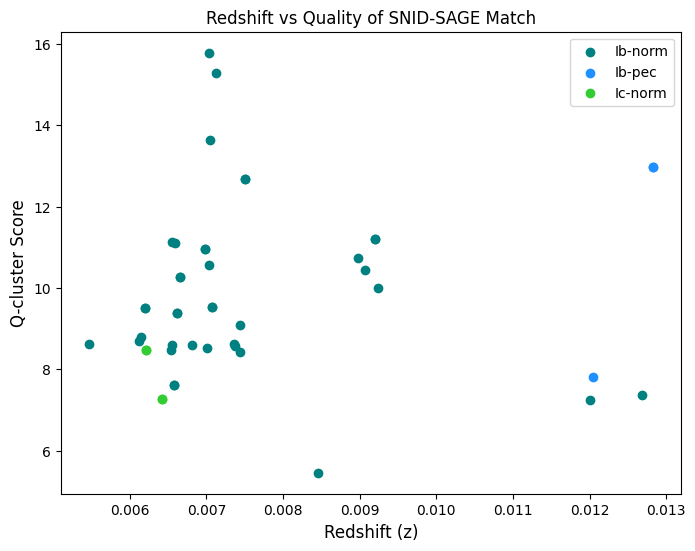

In [675]:
## Redshift Plot (superflous)
plt.figure(figsize = (8,6))

labeled_groups = set()

for i in range(len(confident_df)):
    row = confident_df.iloc[i]

    # #report type first
    # if row.type not in labeled_groups:
    #     plt.scatter(row.z, row.Q_cluster, color = colors[row.type], label = row.type)
    #     labeled_groups.add(row.type)
    # else:
    #     plt.scatter(row.z, row.Q_cluster, color = colors[row.type])

    #report subtype (norm registers as the same)
    if row.subtype not in labeled_groups:
        plt.scatter(row.z, row.Q_cluster, color = colors[row.subtype], label = row.subtype)
        labeled_groups.add(row.subtype)
    else:
        plt.scatter(row.z, row.Q_cluster, color = colors[row.subtype])
    
plt.title("Redshift vs Quality of SNID-SAGE Match")    
plt.xlabel("Redshift (z)", fontsize = 12)
plt.ylabel("Q-cluster Score", fontsize = 12)
plt.legend(loc="upper right")

In [673]:
# plot novel transitions
import matplotlib.pyplot as plt

# Determine how many plots you need
items_to_plot = legit_events.iterrows
num_plots = len(legit_events)

# Setup the figure
fig, axes = plt.subplots(num_plots, 1, figsize=(10, 5 * num_plots))

# Handle when only 1 plot is created 
if num_plots == 1:
    axes = [axes] #(plt.subplots returns a single object instead of a list)

# Loop through IDs
for ax, sn_type in zip(axes, items_to_plot):
    # Filter data for this specific plot
    data = legit_events[legit_events['type'] == sn_type]
    
    # Plotting logic
    ax.plot(data['date'], data['confidence'], marker='o', label=sn_type)
    
    # Formatting
    ax.set_title(f"Evolution for {sn_type}")
    ax.set_ylabel("Confidence")
    ax.grid(True, alpha=0.3)

# 4. Global cleanup
plt.tight_layout()
plt.show()

TypeError: object of type 'method' has no len()

In [281]:
#this doesnt catch transitions going back and forth between the two 
#this doesn't catch subtypes with the same type 
#they match to themselves!!!!!!!! problem 